In [2]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


In [3]:
## Single gene-trait association plot
gene_name = 'LDLR'

In [4]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""regulatory""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1
"""regulatory""","""promoterai_under""","""#00A99D""","""PromoterAI under""",-1
"""regulatory""","""promoterai_over""","""#00A99D""","""PromoterAI over""",1


In [27]:
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet").filter(pl.col('gene_name') == gene_name)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

min_range = -100
max_range = +100

anno = (
    anno
    .filter(
        (pl.col('dist_to_tss') >= min_range) &
        (pl.col('dist_to_tss') <= max_range)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Get gene_id to get olink protein
olink_prot = anno['region'].unique()[0] + '_olink'

anno

promoterai_abs,am_pathogenicity,absplice_dna_max,region,TSS,gene_name,zooverphylop,gpn_star_llr_calibrated_mean,promoterai,relative_cds_position,dist_to_tss,gene_length,id,Strand,loftee_hc,esmscoremissense,promoterai_over,gpn_score,abexp_min,cadd_raw,abexp_max,pangolin_score,verphylop,absplice2_max,promoterai_under,delta_score
f32,f32,f32,str,i64,str,f32,f64,f32,f32,i64,i64,str,cat,i8,f32,f32,f32,f64,f32,f64,f32,f32,f32,f32,f32
0.7858,0.0,0.0,"""ENSG00000130164""",11089461,"""LDLR""",8.768,-6.630163,-0.7858,0.0,-54,44360,"""chr19:11089407:C:G""","""+""",0,0.0,0.0,-6.39,-0.015315,3.203522,-0.014938,0.0,3.531,0.0,-0.7858,0.0
0.1758,0.0,0.001,"""ENSG00000130164""",11089461,"""LDLR""",2.043,-0.225228,-0.1758,0.0,37,44360,"""chr19:11089498:C:T""","""+""",0,0.0,0.0,-1.41,-0.019895,0.7626,-0.010663,0.0,-0.239,0.000033,-0.1758,0.0
0.0834,0.0,0.001,"""ENSG00000130164""",11089461,"""LDLR""",-1.393,2.025872,-0.0834,0.0,32,44360,"""chr19:11089493:T:C""","""+""",0,0.0,0.0,-0.05,-0.011794,-0.26411,-0.005501,0.0,-2.489,0.000033,-0.0834,0.0
0.8664,0.0,0.0,"""ENSG00000130164""",11089461,"""LDLR""",5.615,-6.2878,-0.8664,0.0,-47,44360,"""chr19:11089414:C:G""","""+""",0,0.0,0.0,-7.05,-0.012352,2.4029,-0.011976,0.0,2.156,0.0,-0.8664,0.0
0.0252,0.0,0.003,"""ENSG00000130164""",11089461,"""LDLR""",0.944,-0.042564,0.0252,0.0,63,44360,"""chr19:11089524:A:T""","""+""",0,0.0,0.0252,-1.58,-0.055183,0.935437,-0.014885,0.01,0.503,0.000327,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.7544,0.0,0.0,"""ENSG00000130164""",11089461,"""LDLR""",6.926,-6.95614,-0.7544,0.0,-99,44360,"""chr19:11089362:C:T""","""+""",0,0.0,0.0,-6.12,-0.014533,2.47843,-0.014157,0.0,3.44,0.0,-0.7544,0.0
0.0,0.0,0.0,"""ENSG00000130164""",11089461,"""LDLR""",-0.146,null,0.0,0.0,85,44360,"""chr19:11089546:AG:A""","""+""",0,0.0,0.0,-1.46,null,0.0,null,0.0,0.042,0.0,0.0,0.0
0.0,0.0,0.0,"""ENSG00000130164""",11089461,"""LDLR""",-0.146,null,0.0,0.0,89,44360,"""chr19:11089550:TG:T""","""+""",1,0.0,0.0,-1.46,null,0.0,null,0.0,0.042,0.0,0.0,0.0


In [28]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11089407:C:G""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11089498:C:T""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11089493:T:C""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11089414:C:G""","""ENSG00000130164""","""loftee_hc""",0.0
"""chr19:11089524:A:T""","""ENSG00000130164""","""loftee_hc""",0.0
…,…,…,…
"""chr19:11089362:C:T""","""ENSG00000130164""","""abexp_max""",-0.014157
"""chr19:11089546:AG:A""","""ENSG00000130164""","""abexp_max""",null
"""chr19:11089550:TG:T""","""ENSG00000130164""","""abexp_max""",null


In [29]:
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

olink_appv = (
    olink_appv
    .rename({
        'phenotype': 'olink_prot',
        'mean_pheno_value': 'mean_olink_value',
        'std_pheno_value': 'std_olink_value',
    })
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac) &
        (pl.col('olink_prot') == olink_prot)
    )
)

olink_appv.head().collect()

id,olink_prot,n_individuals,mean_olink_value,std_olink_value
str,str,u64,f32,f32
"""chr19:11089502:G:T""","""ENSG00000130164_olink""",1,-0.055333,null
"""chr19:11089461:G:A""","""ENSG00000130164_olink""",1,-0.108945,null
"""chr19:11089517:G:T""","""ENSG00000130164_olink""",1,-0.948944,null
"""chr19:11089405:A:C""","""ENSG00000130164_olink""",4,0.510604,1.065637
"""chr19:11089526:A:C""","""ENSG00000130164_olink""",2,-0.1763,0.239606


In [30]:
# Merge olink, phenotype, and annotation data
og_df = (
    olink_appv
    .join(
        melted_anno.lazy(),
        on="id",
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).lazy(),
        on=['id', 'region'],
        how='inner'
    )
    .collect(engine='streaming')
)

# Join with experimental data
# og_df = og_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
og_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr19:11089474:G:A""","""ENSG00000130164_olink""",1,0.952203,null,"""ENSG00000130164""","""esmscoremissense""",0.0,11089461,"""+""",44360,"""LDLR""",13
"""chr19:11089405:A:C""","""ENSG00000130164_olink""",4,0.510604,1.065637,"""ENSG00000130164""","""am_pathogenicity""",0.0,11089461,"""+""",44360,"""LDLR""",-56
"""chr19:11089405:A:C""","""ENSG00000130164_olink""",4,0.510604,1.065637,"""ENSG00000130164""","""esmscoremissense""",0.0,11089461,"""+""",44360,"""LDLR""",-56
"""chr19:11089448:T:C""","""ENSG00000130164_olink""",1,0.483378,null,"""ENSG00000130164""","""am_pathogenicity""",0.0,11089461,"""+""",44360,"""LDLR""",-13
"""chr19:11089546:AG:A""","""ENSG00000130164_olink""",1,1.358468,null,"""ENSG00000130164""","""am_pathogenicity""",0.0,11089461,"""+""",44360,"""LDLR""",85
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11089461:G:A""","""ENSG00000130164_olink""",1,-0.108945,null,"""ENSG00000130164""","""absplice_dna_max""",0.0,11089461,"""+""",44360,"""LDLR""",0
"""chr19:11089526:A:C""","""ENSG00000130164_olink""",2,-0.1763,0.239606,"""ENSG00000130164""","""delta_score""",0.0,11089461,"""+""",44360,"""LDLR""",65
"""chr19:11089526:A:C""","""ENSG00000130164_olink""",2,-0.1763,0.239606,"""ENSG00000130164""","""absplice_dna_max""",0.003,11089461,"""+""",44360,"""LDLR""",65


In [31]:
og_df['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""esmscoremissense""",16
"""am_pathogenicity""",16
"""cadd_raw""",16
"""gpn_star_llr_calibrated_mean""",16
"""loftee_hc""",16
…,…
"""promoterai_over""",16
"""abexp_max""",16
"""promoterai_under""",16


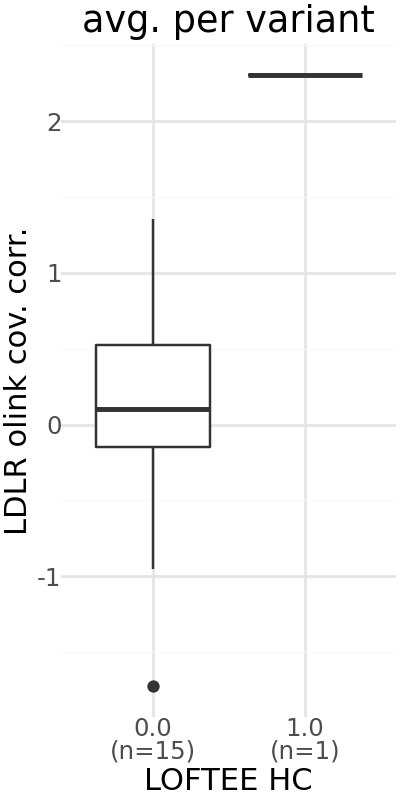

In [32]:
annotation = 'loftee_hc'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    og_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

summary_labels = (
    plot_df
    .group_by(['annotation_score'])
    .agg(n_vars = pl.col('id').len())
    .with_columns(n_label = pl.col('annotation_score').cast(pl.Utf8) + '\n(n=' + pl.col('n_vars').cast(pl.Utf8) + ')')
)

plot_df = plot_df.join(summary_labels, on='annotation_score', how='left')

(
    ggplot(plot_df, aes(x='n_label', y='mean_olink_value')) +
    geom_boxplot(aes(group='n_label')) +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{gene_name} olink cov. corr.",
        title="avg. per variant"
    ) +
    theme(figure_size=(2, 4))
)

In [33]:
phenotype = 'ldl_direct_int'

# Merge olink, genotype and phenotype data
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet")

appv = (
    appv
    .join(
        og_df[['id']].unique().lazy(), on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac) &
        (pl.col('phenotype') == phenotype)
    )
)

ogp_df = (
    og_df.lazy()
    .join(
            appv,
            on="id",
            how="inner"
    )
    .collect(engine='streaming')
    .rename({
        'n_individuals_right': 'n_individuals_appv',
    })
)

ogp_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss,phenotype,n_individuals_appv,mean_pheno_value,std_pheno_value
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64,str,u32,f32,f32
"""chr19:11089502:G:T""","""ENSG00000130164_olink""",1,-0.055333,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",0.25179,11089461,"""+""",44360,"""LDLR""",41,"""ldl_direct_int""",1,-0.019057,null
"""chr19:11089461:G:A""","""ENSG00000130164_olink""",1,-0.108945,null,"""ENSG00000130164""","""esmscoremissense""",0.0,11089461,"""+""",44360,"""LDLR""",0,"""ldl_direct_int""",15,-0.115859,0.683342
"""chr19:11089461:G:A""","""ENSG00000130164_olink""",1,-0.108945,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",-2.707564,11089461,"""+""",44360,"""LDLR""",0,"""ldl_direct_int""",15,-0.115859,0.683342
"""chr19:11089364:C:T""","""ENSG00000130164_olink""",1,0.540594,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",-2.787185,11089461,"""+""",44360,"""LDLR""",-97,"""ldl_direct_int""",2,0.063061,0.10452
"""chr19:11089474:G:A""","""ENSG00000130164_olink""",1,0.952203,null,"""ENSG00000130164""","""gpn_star_llr_calibrated_mean""",-1.547741,11089461,"""+""",44360,"""LDLR""",13,"""ldl_direct_int""",1,0.081006,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11089523:G:A""","""ENSG00000130164_olink""",1,-0.8685,null,"""ENSG00000130164""","""promoterai_abs""",0.0621,11089461,"""+""",44360,"""LDLR""",62,"""ldl_direct_int""",3,0.112577,0.863519
"""chr19:11089428:T:C""","""ENSG00000130164_olink""",35,0.101753,1.181681,"""ENSG00000130164""","""promoterai_abs""",0.346,11089461,"""+""",44360,"""LDLR""",-33,"""ldl_direct_int""",284,0.230678,1.087918
"""chr19:11089428:T:C""","""ENSG00000130164_olink""",35,0.101753,1.181681,"""ENSG00000130164""","""promoterai_under""",-0.346,11089461,"""+""",44360,"""LDLR""",-33,"""ldl_direct_int""",284,0.230678,1.087918


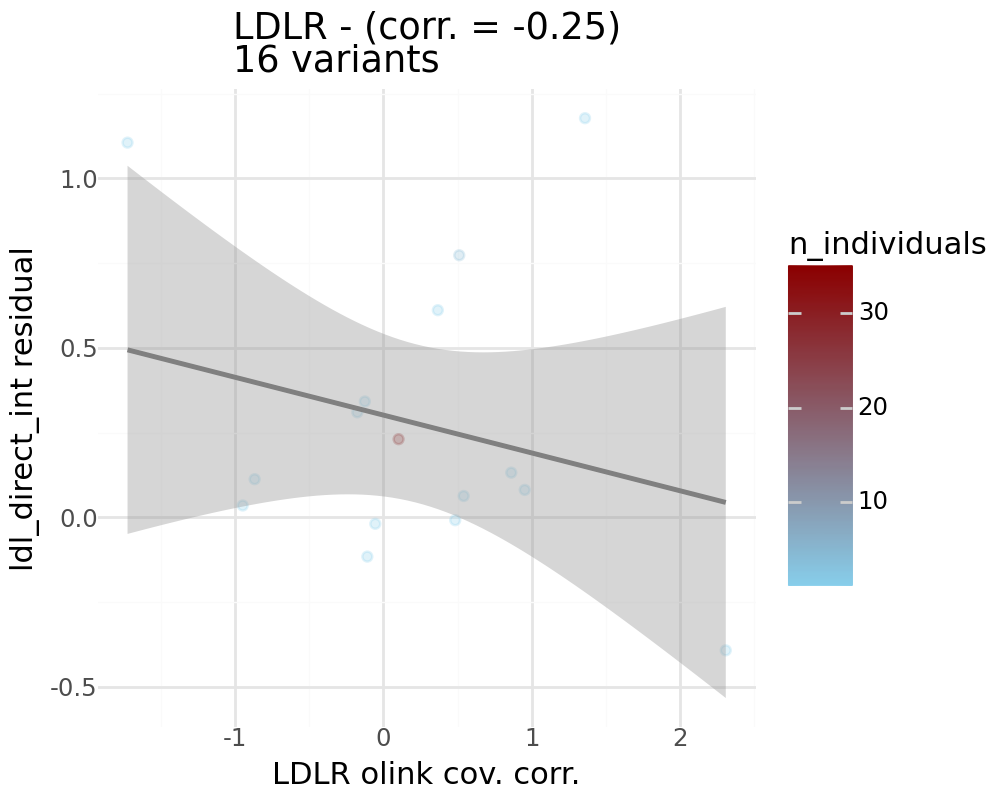

In [34]:
plot_df = ogp_df[['id', 'mean_olink_value', 'mean_pheno_value', 'n_individuals']].unique()

(
    ggplot(plot_df, aes(x='mean_olink_value', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=0.25) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='skyblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{gene_name} olink cov. corr.",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('mean_olink_value', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


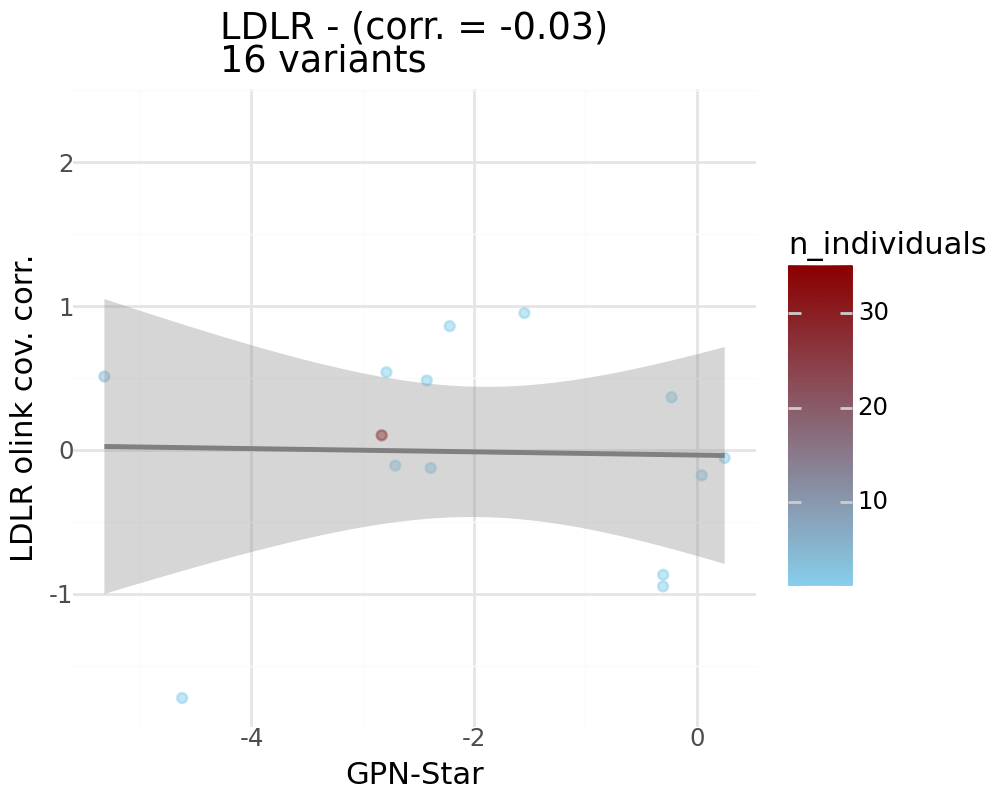

In [35]:
annotation = 'gpn_star_llr_calibrated_mean'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    og_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='skyblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{gene_name} olink cov. corr.",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_olink_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


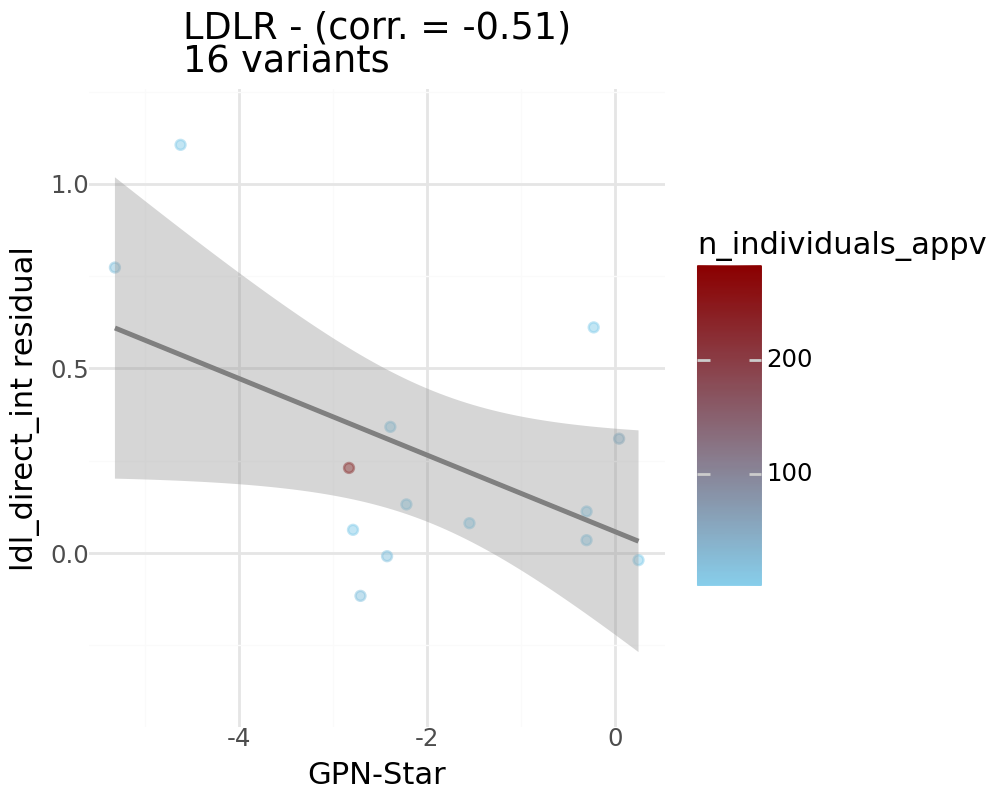

In [36]:
annotation = 'gpn_star_llr_calibrated_mean'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    ogp_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals_appv')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='skyblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)